# Solar Orbiter HET data

In [1]:
import speasy as spz
%matplotlib widget
# Use this instead if you are not using jupyterlab yet
#%matplotlib notebook

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np


Matplotlib is building the font cache; this may take a moment.
server availability check implementation can't be performed in WASM environment, assuming server is up
server availability check implementation can't be performed in WASM environment, assuming server is up
CSA webservice is not supported in WASM environment, disabling CSA provider
server availability check implementation can't be performed in WASM environment, assuming server is up
server availability check implementation can't be performed in WASM environment, assuming server is up
server availability check implementation can't be performed in WASM environment, assuming server is up
Non compliant ISTP file: Epoch was marked as data variable but it has 0 support variable
server availability check implementation can't be performed in WASM environment, assuming server is up


In [2]:
start = "2020-11-28T00:00:00"
stop = "2020-12-05T00:00:00"

## Solar Orbiter electron flux

In [3]:
solo_eflux:spz.SpeasyVariable = spz.get_data("amda/solo_het_omni_eflux", start, stop)

In [4]:
print(np.unique(np.diff(solo_eflux.time), return_counts=True))

(array([1000000000, 1001000000], dtype='timedelta64[ns]'), array([603798,   1000]))


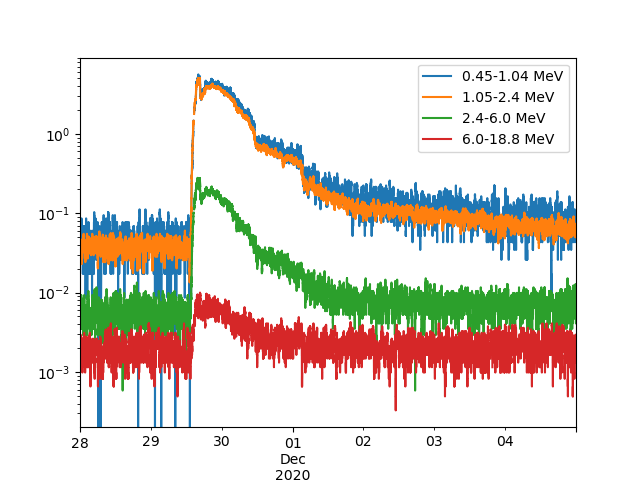

In [5]:
eflux_df = solo_eflux.to_dataframe()
# resample to 1s
eflux_df = eflux_df.resample("1s").ffill()
eflux_df.rolling(600).mean().plot()
plt.yscale("log")

## Solar Orbiter proton flux

In [6]:
solo_hflux:spz.SpeasyVariable = spz.get_data("amda/solo_het_omni_hhcflux", start, stop)

In [7]:
print(np.unique(np.diff(solo_eflux.time), return_counts=True))

(array([1000000000, 1001000000], dtype='timedelta64[ns]'), array([603798,   1000]))


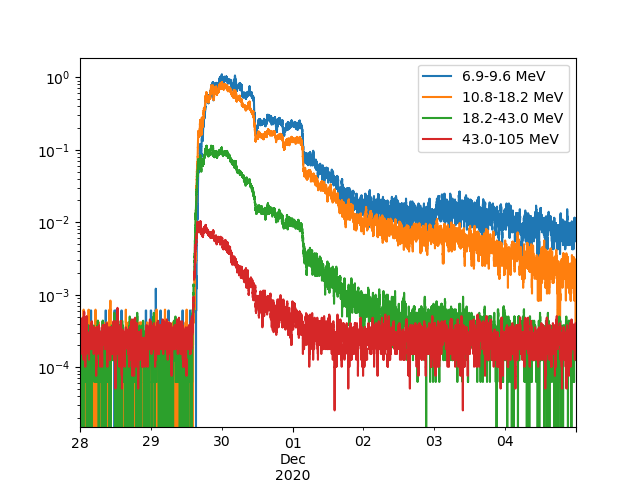

In [8]:
hflux_df = solo_hflux.to_dataframe()
# resample to 1s
hflux_df = hflux_df.resample("1s").ffill()
hflux_df.rolling(600).mean().plot()
plt.yscale("log")

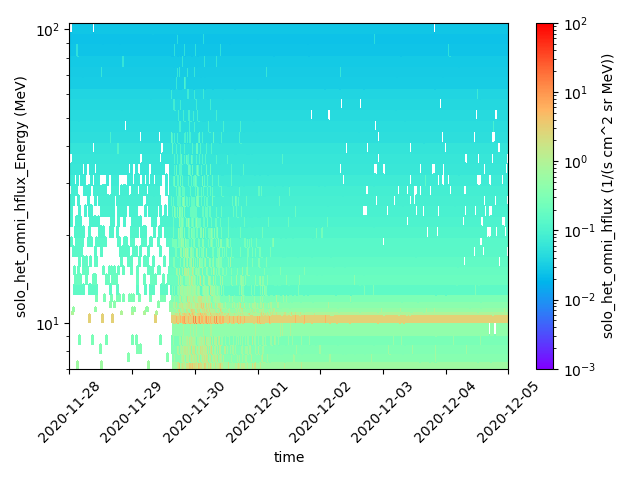

In [9]:
plt.figure()
pas_omni:spz.SpeasyVariable = spz.get_data("amda/solo_het_omni_hflux", start, stop)
pas_omni.plot(cmap='rainbow', vmin=1e-3, vmax=1e2, edgecolors="face")
plt.tight_layout()